In [1]:
# -- Libraries --
import obspy
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import csv
from matplotlib.ticker import MaxNLocator
import time
from datetime import datetime

In [ ]:
# -- FDSN catalogs --
catalogs = {
    'usgs': Client("USGS"),
    'earthscope': Client("EARTHSCOPE"),
    'eth': Client("ETH"),
    'geonet': Client("GEONET"),
    'ingv': Client("INGV"),
    'bgr': Client("BGR"),
    'emsc': Client("EMSC"),
    'isc': Client("ISC"),
    'orfeus': Client("ORFEUS"),
    'eposfr': Client("EPOSFR")
}

In [ ]:
# -- Regions --
regions = {
    # localities (bounding box: [minlat, maxlat, minlon, maxlon])
    'world': {'type': 'box', 'coords': [-90.0, 90.0, -180.0, 180.0]},
}

In [ ]:
# -- Functions - Get the data --
def get_earthquake_data_box(params):
    client = params['catalog']
    year = params['year']
    box = params['place']
    minmag = params['minmag']

    return client.get_events(
        minlatitude=box[0],
        maxlatitude=box[1],
        minlongitude=box[2],
        maxlongitude=box[3],
        starttime=f"{year}-01-01",
        endtime=f"{year}-12-31",
        minmagnitude=minmag,
    )

def get_earthquake_data_point(params):
    client = params['catalog']
    year = params['year']
    point = params['place']
    minmag = params['minmag']

    return client.get_events(
        latitude=point[0],
        longitude=point[1],
        maxradius=point[2],
        starttime=f"{year}-01-01",
        endtime=f"{year}-12-31",
        minmagnitude=minmag,
    )

In [ ]:
# -- Functions - get and print data --
def retrieve_data(params):
    catalog_key = params['catalog_key']
    place_name = params['place_name']
    minmag = params['minmag']
    years = params['years']

    catalog = catalogs[catalog_key]
    place = regions[place_name]

    data = []
    for year in years:
        ps = {
            'catalog': catalog,
            'year': year,
            'place': place['coords'],
            'minmag': minmag
        }
        try:
            if place['type'] == 'box':
                eq_data = get_earthquake_data_box(ps)
            elif place['type'] == 'point':
                eq_data = get_earthquake_data_point(ps)
            else:
                raise ValueError("Neznámy typ oblasti.")
            print(f"data: {place_name} ({catalog_key}), year: {year}, number of earthquakes: {len(eq_data)}")
            data.append({'year': year, 'count': len(eq_data)})
        except Exception as e:
            print(f"Error in year {year}: {e}")
            data.append({'year': year, 'count': None})

    return data

def print_data(data):
    for item in data:
        print(f"Year: {item['year']}, Number of Earthquakes: {item['count']}")

def plot_data(data, params, regions):
    catalog_key = params['catalog_key']
    place_name = params['place_name']
    minmag = params['minmag']

    years_list = [d['year'] for d in data]
    counts = [d['count'] for d in data]

    # sort by year
    years_list, counts = zip(*sorted(zip(years_list, counts)))

    catalog_name = catalog_key.upper()
    place_label = place_name.replace("_", " ").title()
    coords = regions[place_name]['coords']
    if regions[place_name]['type'] == 'box':
        coords_text = f"{coords[2]}°E–{coords[3]}°E, {coords[0]}°S–{coords[1]}°N"
    else:
        coords_text = f"Center: {coords[0]}°N, {coords[1]}°E, radius {coords[2]}°"

    # plot
    plt.figure(figsize=(10, 5))
    plt.plot(years_list, counts, marker='o')
    plt.grid(True)
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xlabel('Year')
    plt.ylabel('Number of Earthquakes')
    plt.title(
        f'Number of Earthquakes per Year in {place_label} '
        f'with M≥{minmag}, Data from {catalog_name}'
    )
    plt.figtext(
        0.5, -0.05,
        f"Source: {catalog_name.upper()} catalog. "
        f"{place_name.replace('_',' ').title()}: {coords_text}",
        wrap=True, ha='center', fontsize=9
    )
    # Set x-ticks to show every 5 years
    plt.xticks(ticks=range(years_list[0], years_list[-1]+1, 5))
    plt.tight_layout()
    plt.show()

def save_data_to_csv(data, params, regions):
    catalog_key = params['catalog_key']
    place_name = params['place_name']
    minmag = params['minmag']

    # -- Save CSV --
    coords = regions[place_name]['coords']
    if regions[place_name]['type'] == 'box':
        coord_text = f"{coords[0]}_{coords[1]}_{coords[2]}_{coords[3]}"  # latmin_latmax_lonmin_lonmax
    else:
        coord_text = f"{coords[0]}_{coords[1]}_{coords[2]}"  # lat_lon_radius

    current_datetime = datetime.now()

    path_to_file = "./data/"
    import os
    if not os.path.exists(path_to_file):
        os.makedirs(path_to_file)

    filename = path_to_file + f"earthquakes_{place_name}_Mgt{minmag}_{catalog_key}_{coord_text}_{current_datetime.strftime('%Y%m%d_%H%M')}.csv"
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=['year', 'count'])
        writer.writeheader()
        writer.writerows(data)

    print(f"Dáta uložené do súboru: {filename}")
    return filename


data: world (usgs), year: 1980, number of earthquakes: 4834
data: world (usgs), year: 1981, number of earthquakes: 4428
data: world (usgs), year: 1982, number of earthquakes: 4690
data: world (usgs), year: 1983, number of earthquakes: 5307
data: world (usgs), year: 1984, number of earthquakes: 5276
data: world (usgs), year: 1985, number of earthquakes: 6031
data: world (usgs), year: 1986, number of earthquakes: 6202
data: world (usgs), year: 1987, number of earthquakes: 5666
data: world (usgs), year: 1988, number of earthquakes: 5510
data: world (usgs), year: 1989, number of earthquakes: 5573
data: world (usgs), year: 1990, number of earthquakes: 6192
data: world (usgs), year: 1991, number of earthquakes: 5878
data: world (usgs), year: 1992, number of earthquakes: 6784
data: world (usgs), year: 1993, number of earthquakes: 6495
data: world (usgs), year: 1994, number of earthquakes: 6131
data: world (usgs), year: 1995, number of earthquakes: 9528
data: world (usgs), year: 1996, number o

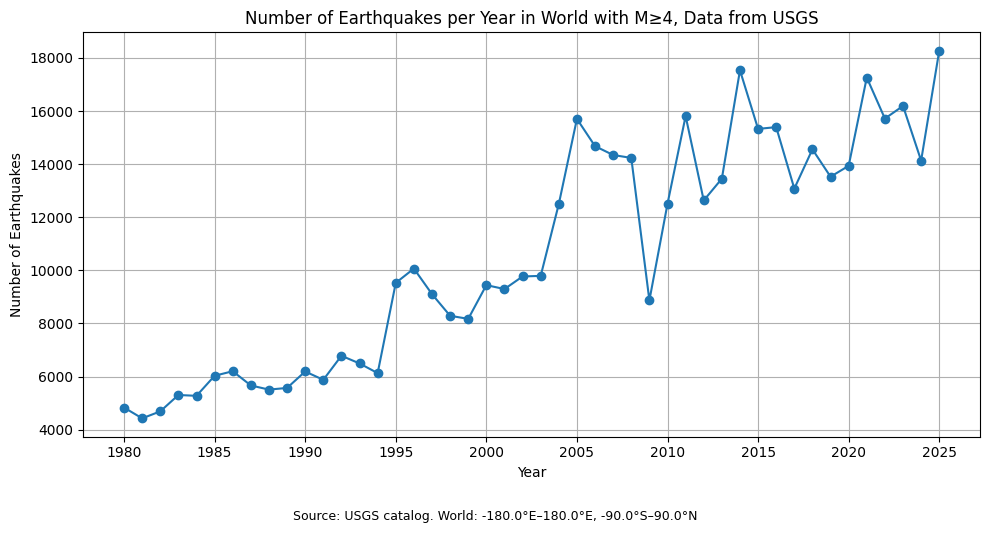

Dáta uložené do súboru: ./data/earthquakes_world_Mgt4_usgs_-90.0_90.0_-180.0_180.0_20260328_2258.csv


In [11]:
# parameters
params = {
    'catalog_key': 'usgs',      # select catalog
    'place_name': 'world',      # select area or supervolcano
    'minmag': 4,              # minimum magnitude
    'years': range(1980, 2026)
}
data = retrieve_data(params)
plot_data(data, params, regions)
filename = save_data_to_csv(data, params, regions)
